> # ***Introduction***

Metabolic dysfunction-associated steatotic liver disease (MASLD), formerly known as non-alcoholic fatty liver disease (NAFLD), is one of the most common chronic liver conditions worldwide, affecting an estimated 25–30% of the global population. It is characterized by excessive fat accumulation in the liver (hepatic steatosis) in the absence of significant alcohol consumption, and is closely linked to obesity, type 2 diabetes, and metabolic syndrome.

MASLD exists on a spectrum of severity — from simple steatosis (fat accumulation with minimal inflammation) to steatohepatitis, fibrosis, and eventually cirrhosis if left untreated. Early and accurate detection is essential, since the disease is often asymptomatic in its initial stages but can progress silently toward serious liver damage.

Two complementary diagnostic tools are commonly used to assess MASLD:

Ultrasound imaging, which provides a non-invasive visual assessment of liver echogenicity and is typically used to grade the severity of steatosis (e.g., Grade 1: mild, Grade 2: moderate, Grade 3: severe).
FibroScan (transient elastography), which measures liver stiffness and fat content to estimate two key clinical parameters:
Fibrosis stage (ranging from F0/F1 – no or minimal fibrosis, to advanced fibrosis stages), reflecting the degree of liver scarring.
Steatosis stage (ranging from S0 – normal, to higher grades), reflecting the extent of fat accumulation.
About This Dataset

This notebook combines two complementary sources of data for MASLD patients:

Radiology dataset — a collection of liver ultrasound images organized by steatosis grade (Grade_1, Grade_2, Grade_3), each paired with a corresponding segmentation mask highlighting the region of interest in the liver.
FibroScan results — clinical measurements for each patient, including fibrosis stage and steatosis stage, obtained through transient elastography.

By linking the imaging data with the corresponding clinical FibroScan measurements for each patient, this combined dataset enables the development of models that connect visual liver characteristics with quantitative clinical severity indicators — supporting research into automated, image-based assessment of MASLD severity as a potential complement to invasive diagnostic procedures such as liver biopsy.

In [1]:
import os 
import cv2
import json
import re
import difflib
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings 
warnings.filterwarnings('ignore')

from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, MaxPooling2D , GlobalAveragePooling2D,Dropout,BatchNormalization,Input,Flatten,Dense
from tensorflow.keras.applications import EfficientNetB0 ,DenseNet121,ResNet50

from IPython.display import clear_output
!pip install tf_explain
clear_output()

from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from tf_explain.core.grad_cam import GradCAM

from keras.metrics import MeanIoU

In [2]:
BASE_PATH = "/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset"
data = []

# Grades
for grade in ["Grade_1", "Grade_2", "Grade_3"]:
    
    radiology_dir = os.path.join(BASE_PATH, grade, "Radiology")
    masks_dir = os.path.join(BASE_PATH, grade, "Masks")
    
    radiology_files = os.listdir(radiology_dir)
    
    for radiology_file in radiology_files:
        
        if not radiology_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
    
        image_id = os.path.splitext(radiology_file)[0]
        
        mask_file = image_id + ".png"
        mask_path = os.path.join(masks_dir, mask_file)
        
        radiology_path = os.path.join(radiology_dir, radiology_file)
        
        if os.path.exists(mask_path):
            
            data.append({
                "image_path": radiology_path,
                "mask_path": mask_path,
                "grade": grade
            })

df = pd.DataFrame(data)

print("Number of samples:", len(df))
df.head()

Number of samples: 2031


,image_path,mask_path,grade
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


In [3]:
patients = pd.read_excel("/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/Patients.xlsx")
fibro = pd.read_csv("/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset/fibroscan_results.csv")

def extract_id_from_image_path(path):
    filename = os.path.splitext(os.path.basename(path))[0]  
    base_id = re.sub(r'_\d+$', '', filename)
    return base_id

df["patient_id"] = df["image_path"].apply(extract_id_from_image_path)

def extract_id_from_image_name(name):
    filename = os.path.splitext(name)[0]  
    base_id = re.sub(r'_fibroscan$', '', filename)
    return base_id


fibro["patient_id"] = fibro["image_name"].apply(extract_id_from_image_name)

df["patient_id"] = df["patient_id"].str.lower()
fibro["patient_id"] = fibro["patient_id"].str.lower()

def norm(x):
    x = str(x).lower().strip()
    x = re.sub(r'\s+', '_', x)
    x = re.sub(r'_+', '_', x)
    return x

def extract_patient_id(img_name):
    base = re.sub(r'\.(jpg|jpeg|png)$', '', img_name, flags=re.I)
    base = re.sub(r'_fibroscan$', '', base, flags=re.I)
    return norm(base)

def extract_name_only(img_name):
    base = re.sub(r'\.(jpg|jpeg|png)$', '', img_name, flags=re.I)
    base = re.sub(r'_fibroscan$', '', base, flags=re.I)
    base = re.sub(r'^organized_dataset\d+_', '', base, flags=re.I)
    base = re.sub(r'_grade_?\d+$', '', base, flags=re.I)
    return norm(base)

fibro["patient_id"] = fibro["image_name"].apply(extract_patient_id)
fibro["name_only"]  = fibro["image_name"].apply(extract_name_only)
patients["name_only"] = patients["Name"].apply(norm)

patients_names = patients["name_only"].tolist()
name_map = {}
for fname in fibro["name_only"].unique():
    matches = difflib.get_close_matches(fname, patients_names, n=1, cutoff=0.7)
    name_map[fname] = matches[0] if matches else None

fibro["patients_name_match"] = fibro["name_only"].map(name_map)
fibro_clinical = pd.merge(
    fibro, patients,
    left_on="patients_name_match", right_on="name_only",
    how="left", suffixes=("", "_patient")
)

print("NUM OF Row fibro:", len(fibro))
print("NOT APPLY", fibro_clinical["Name"].isna().sum(), "ROW")
print(fibro_clinical.loc[fibro_clinical["Name"].isna(), "image_name"].tolist())

corrections = {
    "organized_dataset5_soilman_soady": "organized_dataset5_soliman_soady",
    "organized_dataset5_set_elahl_elayed": "organized_dataset5_set_elahl_elyed",
    "organized_dataset5_soad_mohamed_metwally": "organized_dataset5_soad_mohamed",
}
df["patient_id"] = df["patient_id"].apply(norm).replace(corrections)

final_df = pd.merge(df, fibro_clinical, on="patient_id", how="inner", suffixes=("", "_fibro"))
print("\nFinal NUM OF Rows:", len(final_df))
final_df.head()

NUM OF Row fibro: 142
NOT APPLY 3 ROW
['organized_dataset3_EMAIL_ERENE_fibroscan.jpeg', 'organized_dataset5_email erene.jpeg', 'organized_dataset3_mona_zeinelabdin_fibroscan.jpeg']

Final NUM OF Rows: 2031


,image_path,mask_path,grade,patient_id,image_name,stage_fibrosis,stage_steatosis,Unnamed: 3,name_only,patients_name_match,...,AST,Albumin,Bilubin,weight in KG,height in cm,Height *2,Height in meter,virology,MASLD,name_only_patient
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset1_fatma_ashraf,organized_dataset1_fatma_ashraf_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN,fatma_ashraf,fatma_ashraf,...,17.0,4.9,0.87/0.05,70.0,163.0,2.6569,1.63,negative,True,fatma_ashraf
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset4_gamalat_abdel_moniem,organized_dataset4_Gamalat_abdel_moniem_fibros...,F2-F3 (Significant fibrosis),S0 (Normal),NaN,gamalat_abdel_moniem,gamlat_abdel_moniem,...,14.0,3.7,0.37/0.2,68.0,160.0,2.5600,1.60,negative,False,gamlat_abdel_moniem
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset3_sanaa_mohamed,organized_dataset3_sanaa_mohamed_fibroscan.jpeg,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN,sanaa_mohamed,sanaa_mohamed,...,15.0,4.2,0.5/0.12,72.0,165.0,2.7225,1.65,negative,False,sanaa_mohamed
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset2_aisha_ramadan,organized_dataset2_Aisha_ramadan_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN,aisha_ramadan,aisha_ramadan,...,38.0,3.0,0.8/0.4,79.0,160.0,2.5600,1.60,negative,True,aisha_ramadan
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset4_hamedya_said,organized_dataset4_Hamedya_said_fibroscan.jpg,F3-F4 (Advanced fibrosis),S0 (Normal),NaN,hamedya_said,hamedya_said,...,18.0,3.2,0.33/0.09,70.0,155.0,2.4025,1.55,negative,False,hamedya_said


In [4]:
final_df.columns

Index(['image_path', 'mask_path', 'grade', 'patient_id', 'image_name',
       'stage_fibrosis', 'stage_steatosis', 'Unnamed: 3', 'name_only',
       'patients_name_match', 'Name', 'Gender', 'Age', 'DM', 'HTN', 'BMI',
       'waist circumference (cm)', 'triglceride', 'HDL', 'cholesterol', 'INR',
       'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin', 'Bilubin', 'weight in KG',
       'height in cm ', 'Height *2', 'Height in meter ', 'virology', 'MASLD',
       'name_only_patient'],
      dtype='object')

In [5]:
final_df.drop('Unnamed: 3',axis=1,inplace=True)
final_df.dropna(inplace=True)

In [6]:
final_df['stage_steatosis'].value_counts()

stage_steatosis
S0 (Normal)      1419
S3 (Severe)       360
S1 (Mild)         117
S2 (Moderate)      81
Name: count, dtype: int64

In [7]:
df = final_df.copy()

df.drop([
    'grade',
    'patient_id',
    'patients_name_match',
    'Name',
    'Gender',
    'name_only_patient',
    'image_name',
    'stage_fibrosis'
], axis=1, inplace=True)

In [8]:
df.columns

Index(['image_path', 'mask_path', 'stage_steatosis', 'name_only', 'Age', 'DM',
       'HTN', 'BMI', 'waist circumference (cm)', 'triglceride', 'HDL',
       'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD'],
      dtype='object')

In [9]:
df.loc[df['stage_steatosis']=='S1(Mild)','stage_steatosis'] = 'S1 (Mild)'

In [10]:
df['stage_steatosis'].unique()

array(['S2 (Moderate)', 'S0 (Normal)', 'S3 (Severe)', 'S1 (Mild)'],
      dtype=object)

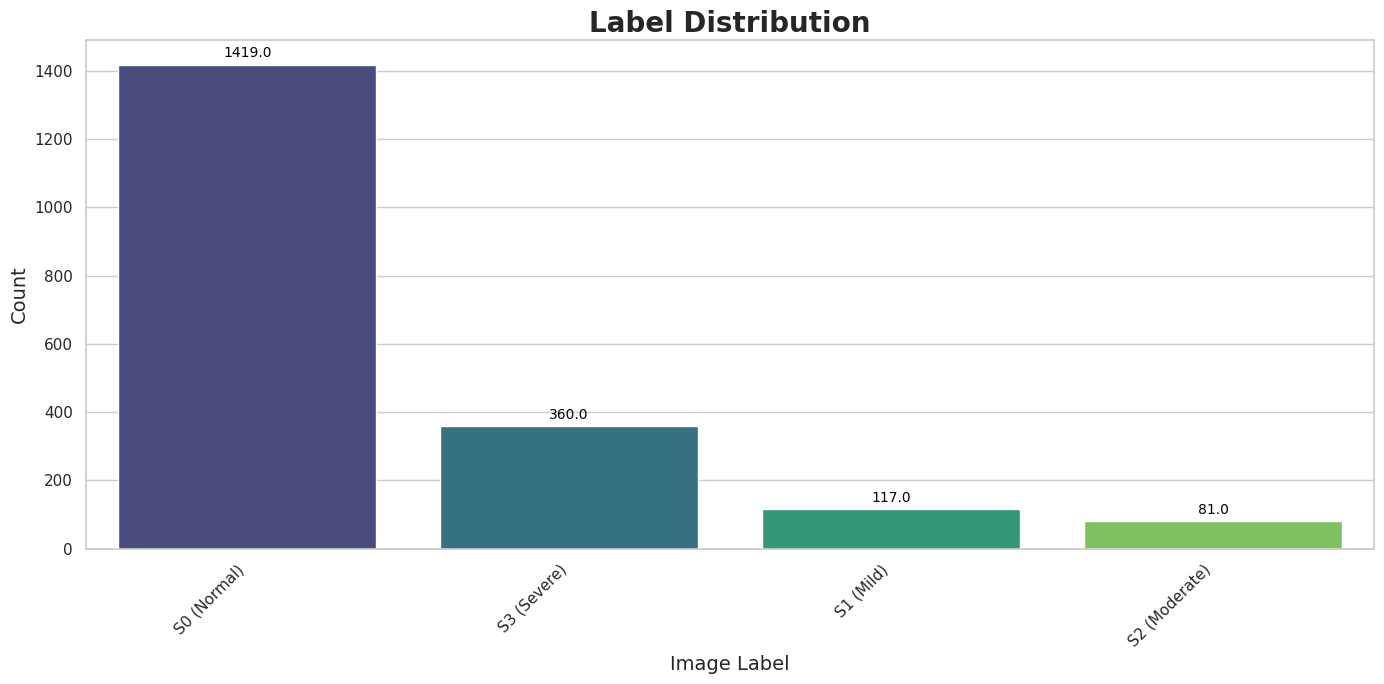

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='stage_steatosis', palette='viridis', order=df['stage_steatosis'].value_counts().index)

plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

In [12]:
df['stage_steatosis'].unique()

array(['S2 (Moderate)', 'S0 (Normal)', 'S3 (Severe)', 'S1 (Mild)'],
      dtype=object)

> # ***Show Sample of Data*** 

In [13]:
df_s0 = df[df['stage_steatosis']=='S0 (Normal)'].head(1)
df_s1 = df[df['stage_steatosis']=='S1 (Mild)'].head(1)
df_s2 = df[df['stage_steatosis']=='S2 (Moderate)'].head(1)
df_s3 = df[df['stage_steatosis']=='S3 (Severe)'].head(1)

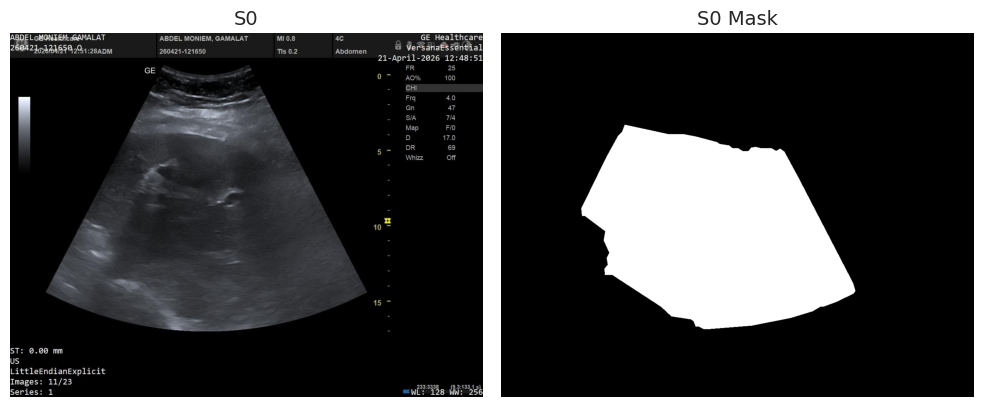

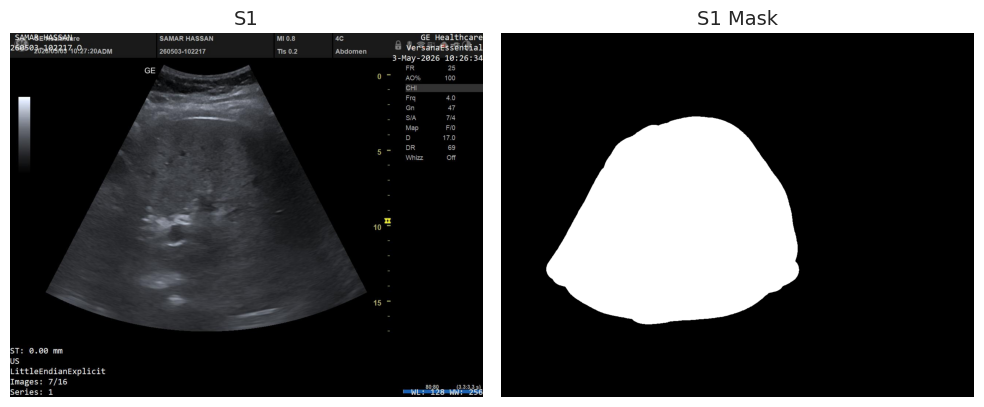

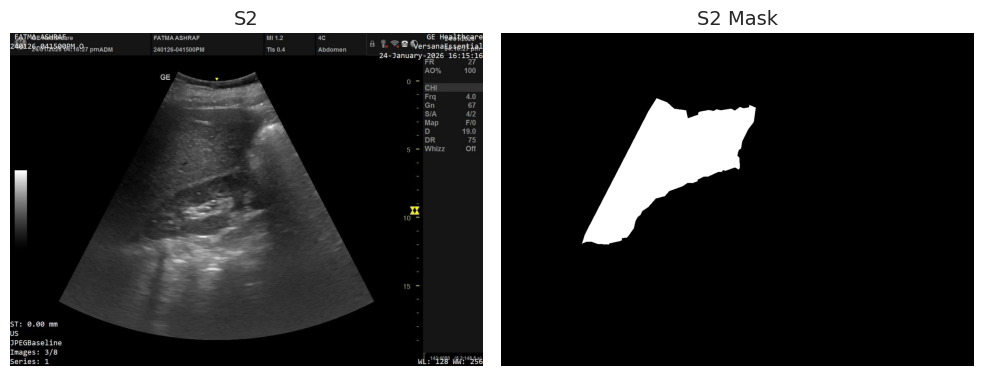

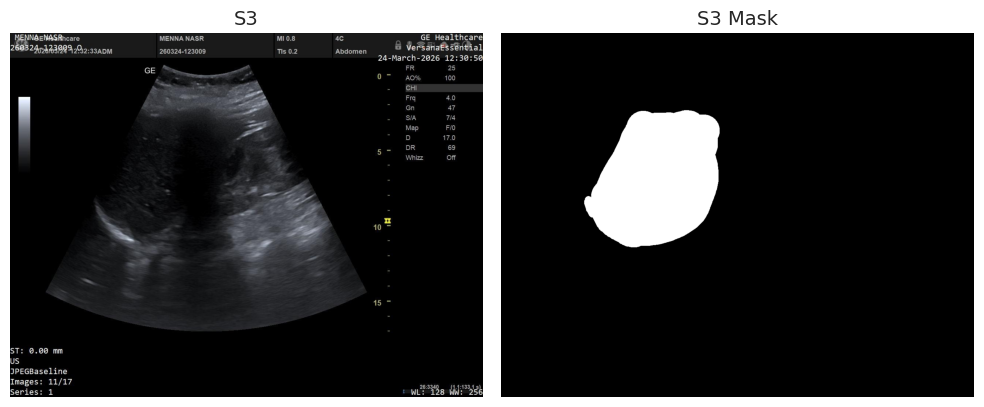

In [14]:
stage_steatosis = {
    "S0": df_s0,
    "S1": df_s1,
    "S2": df_s2,
    "S3": df_s3
}

for steatosis_name, df_steatosis in stage_steatosis.items():

    plt.figure(figsize=(10, 5))
    row = df_steatosis.iloc[0]
    img = Image.open(row["image_path"])
    mask_path = row["mask_path"]

    if isinstance(mask_path, str):
        mask = Image.open(mask_path)
    else:
        mask = None
        
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(steatosis_name, fontsize=14)
    plt.subplot(1, 2, 2)

    if mask is not None:
        plt.imshow(mask, cmap="gray")
        plt.title(f"{steatosis_name} Mask", fontsize=14)
    else:
        plt.title("No Mask")

    plt.axis("off")

    plt.tight_layout()
    plt.show()

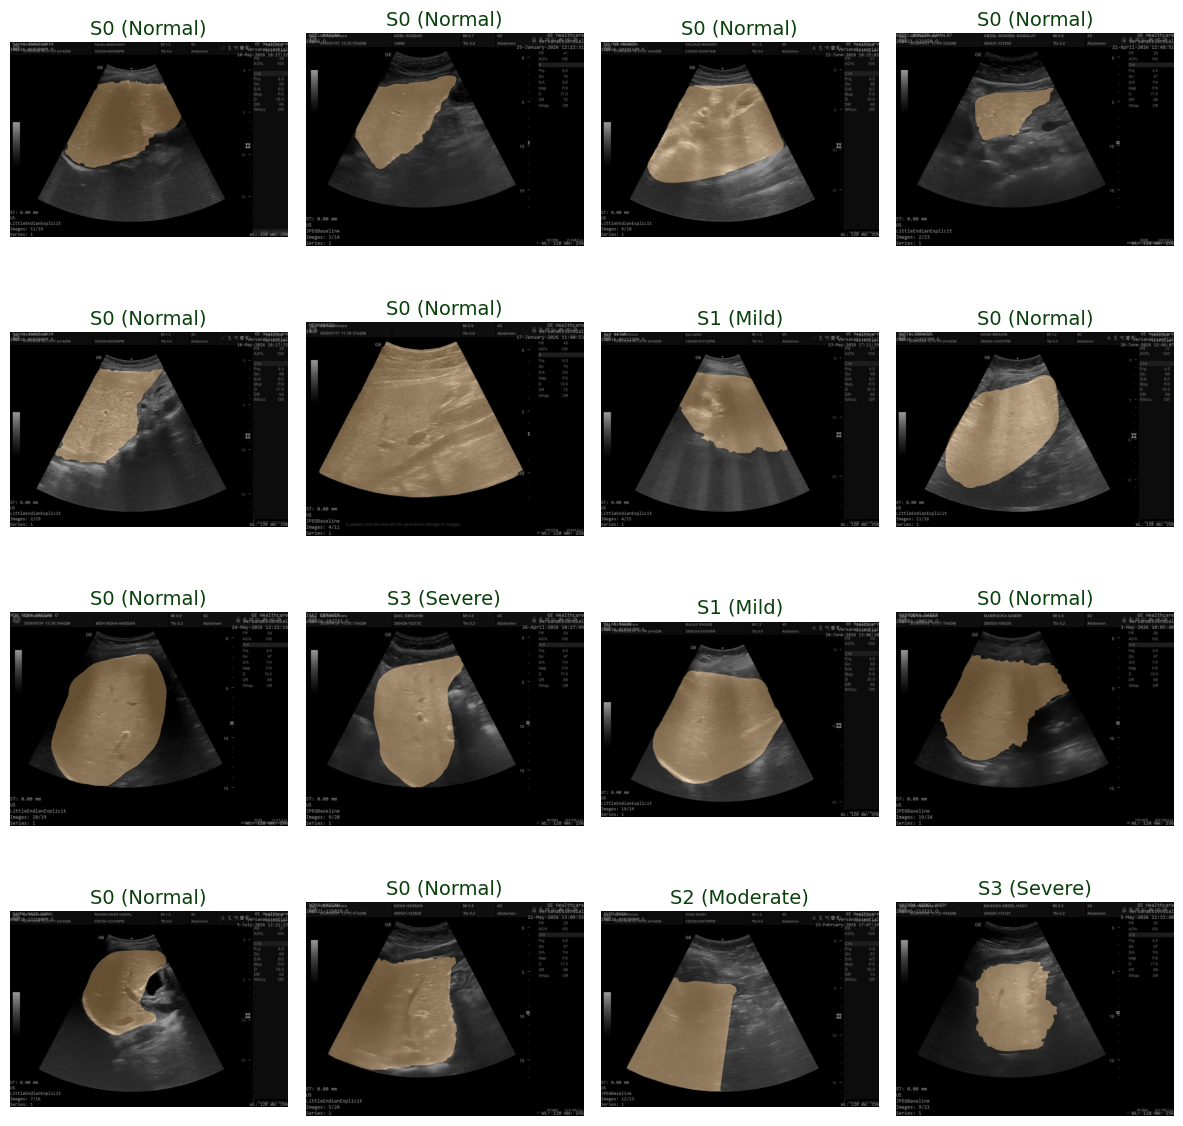

In [15]:
df = df.sample(frac=1).reset_index(drop=True)
plt.figure(figsize=(12, 12))

for i in range(16):
    img_path = df.iloc[i]['image_path']
    img = np.array(Image.open(img_path).convert("L"))
    mask_path = df.iloc[i]['mask_path']

    if isinstance(mask_path, list) and len(mask_path) > 0:
        mask_path = mask_path[0]

    if mask_path is not None:
        mask = np.array(Image.open(mask_path).convert("L"))
    else:
        mask = None
        
    plt.subplot(4, 4, i + 1)

    plt.imshow(img, cmap="gray")
    if mask is not None:
        plt.imshow(mask, cmap="copper", alpha=0.4)
    label_name = df.iloc[i]['stage_steatosis']
    plt.title(label_name, color='#0A400C', fontsize=14)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
batchsize    = 32
image_height = 224
image_width  = 224
num_classes  = 4
epochs       = 200

In [17]:
tabular_df = df.drop([
    'image_path', 
    'mask_path',
    'name_only',
    'stage_steatosis'
],axis=1)
image_df = df.drop([
       'name_only',
       'Age', 'DM', 'HTN', 'BMI', 'waist circumference (cm)', 'triglceride',
       'HDL', 'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD'
],axis=1)

In [18]:
image_df.columns

Index(['image_path', 'mask_path', 'stage_steatosis'], dtype='object')

In [19]:
tabular_df.columns

Index(['Age', 'DM', 'HTN', 'BMI', 'waist circumference (cm)', 'triglceride',
       'HDL', 'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD'],
      dtype='object')

> # ***Image DataFrame*** 

> # ***Split Data*** 

In [20]:
train_df, validation_df = train_test_split(
    df,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=df['stage_steatosis']
)

In [21]:
print("Train:", len(train_df))
print("Validation:", len(validation_df))

print("\nTrain distribution:")
print(train_df['stage_steatosis'].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_df['stage_steatosis'].value_counts(normalize=True))

Train: 1779
Validation: 198

Train distribution:
stage_steatosis
S0 (Normal)      0.717819
S3 (Severe)      0.182125
S1 (Mild)        0.059022
S2 (Moderate)    0.041034
Name: proportion, dtype: float64

Validation distribution:
stage_steatosis
S0 (Normal)      0.717172
S3 (Severe)      0.181818
S1 (Mild)        0.060606
S2 (Moderate)    0.040404
Name: proportion, dtype: float64


> # ***Label Encoder***

In [22]:
class_names = sorted(df['stage_steatosis'].unique())
class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}
train_df['label_id'] = train_df['stage_steatosis'].map(class_to_idx)
validation_df['label_id'] = validation_df['stage_steatosis'].map(class_to_idx)

> # ***Tabular Dataset*** 

In [23]:
train_tabular = train_df[tabular_df.columns].copy()
validation_tabular = validation_df[tabular_df.columns].copy()

In [24]:
label_encoders = {}
categorical_cols= tabular_df.select_dtypes(include="object")
for col in categorical_cols:

    le = LabelEncoder()

    train_tabular[col] = le.fit_transform(
        train_tabular[col].astype(str)
    )

    validation_tabular[col] = le.transform(
        validation_tabular[col].astype(str)
    )

    label_encoders[col] = le

> # ***Scaler*** 

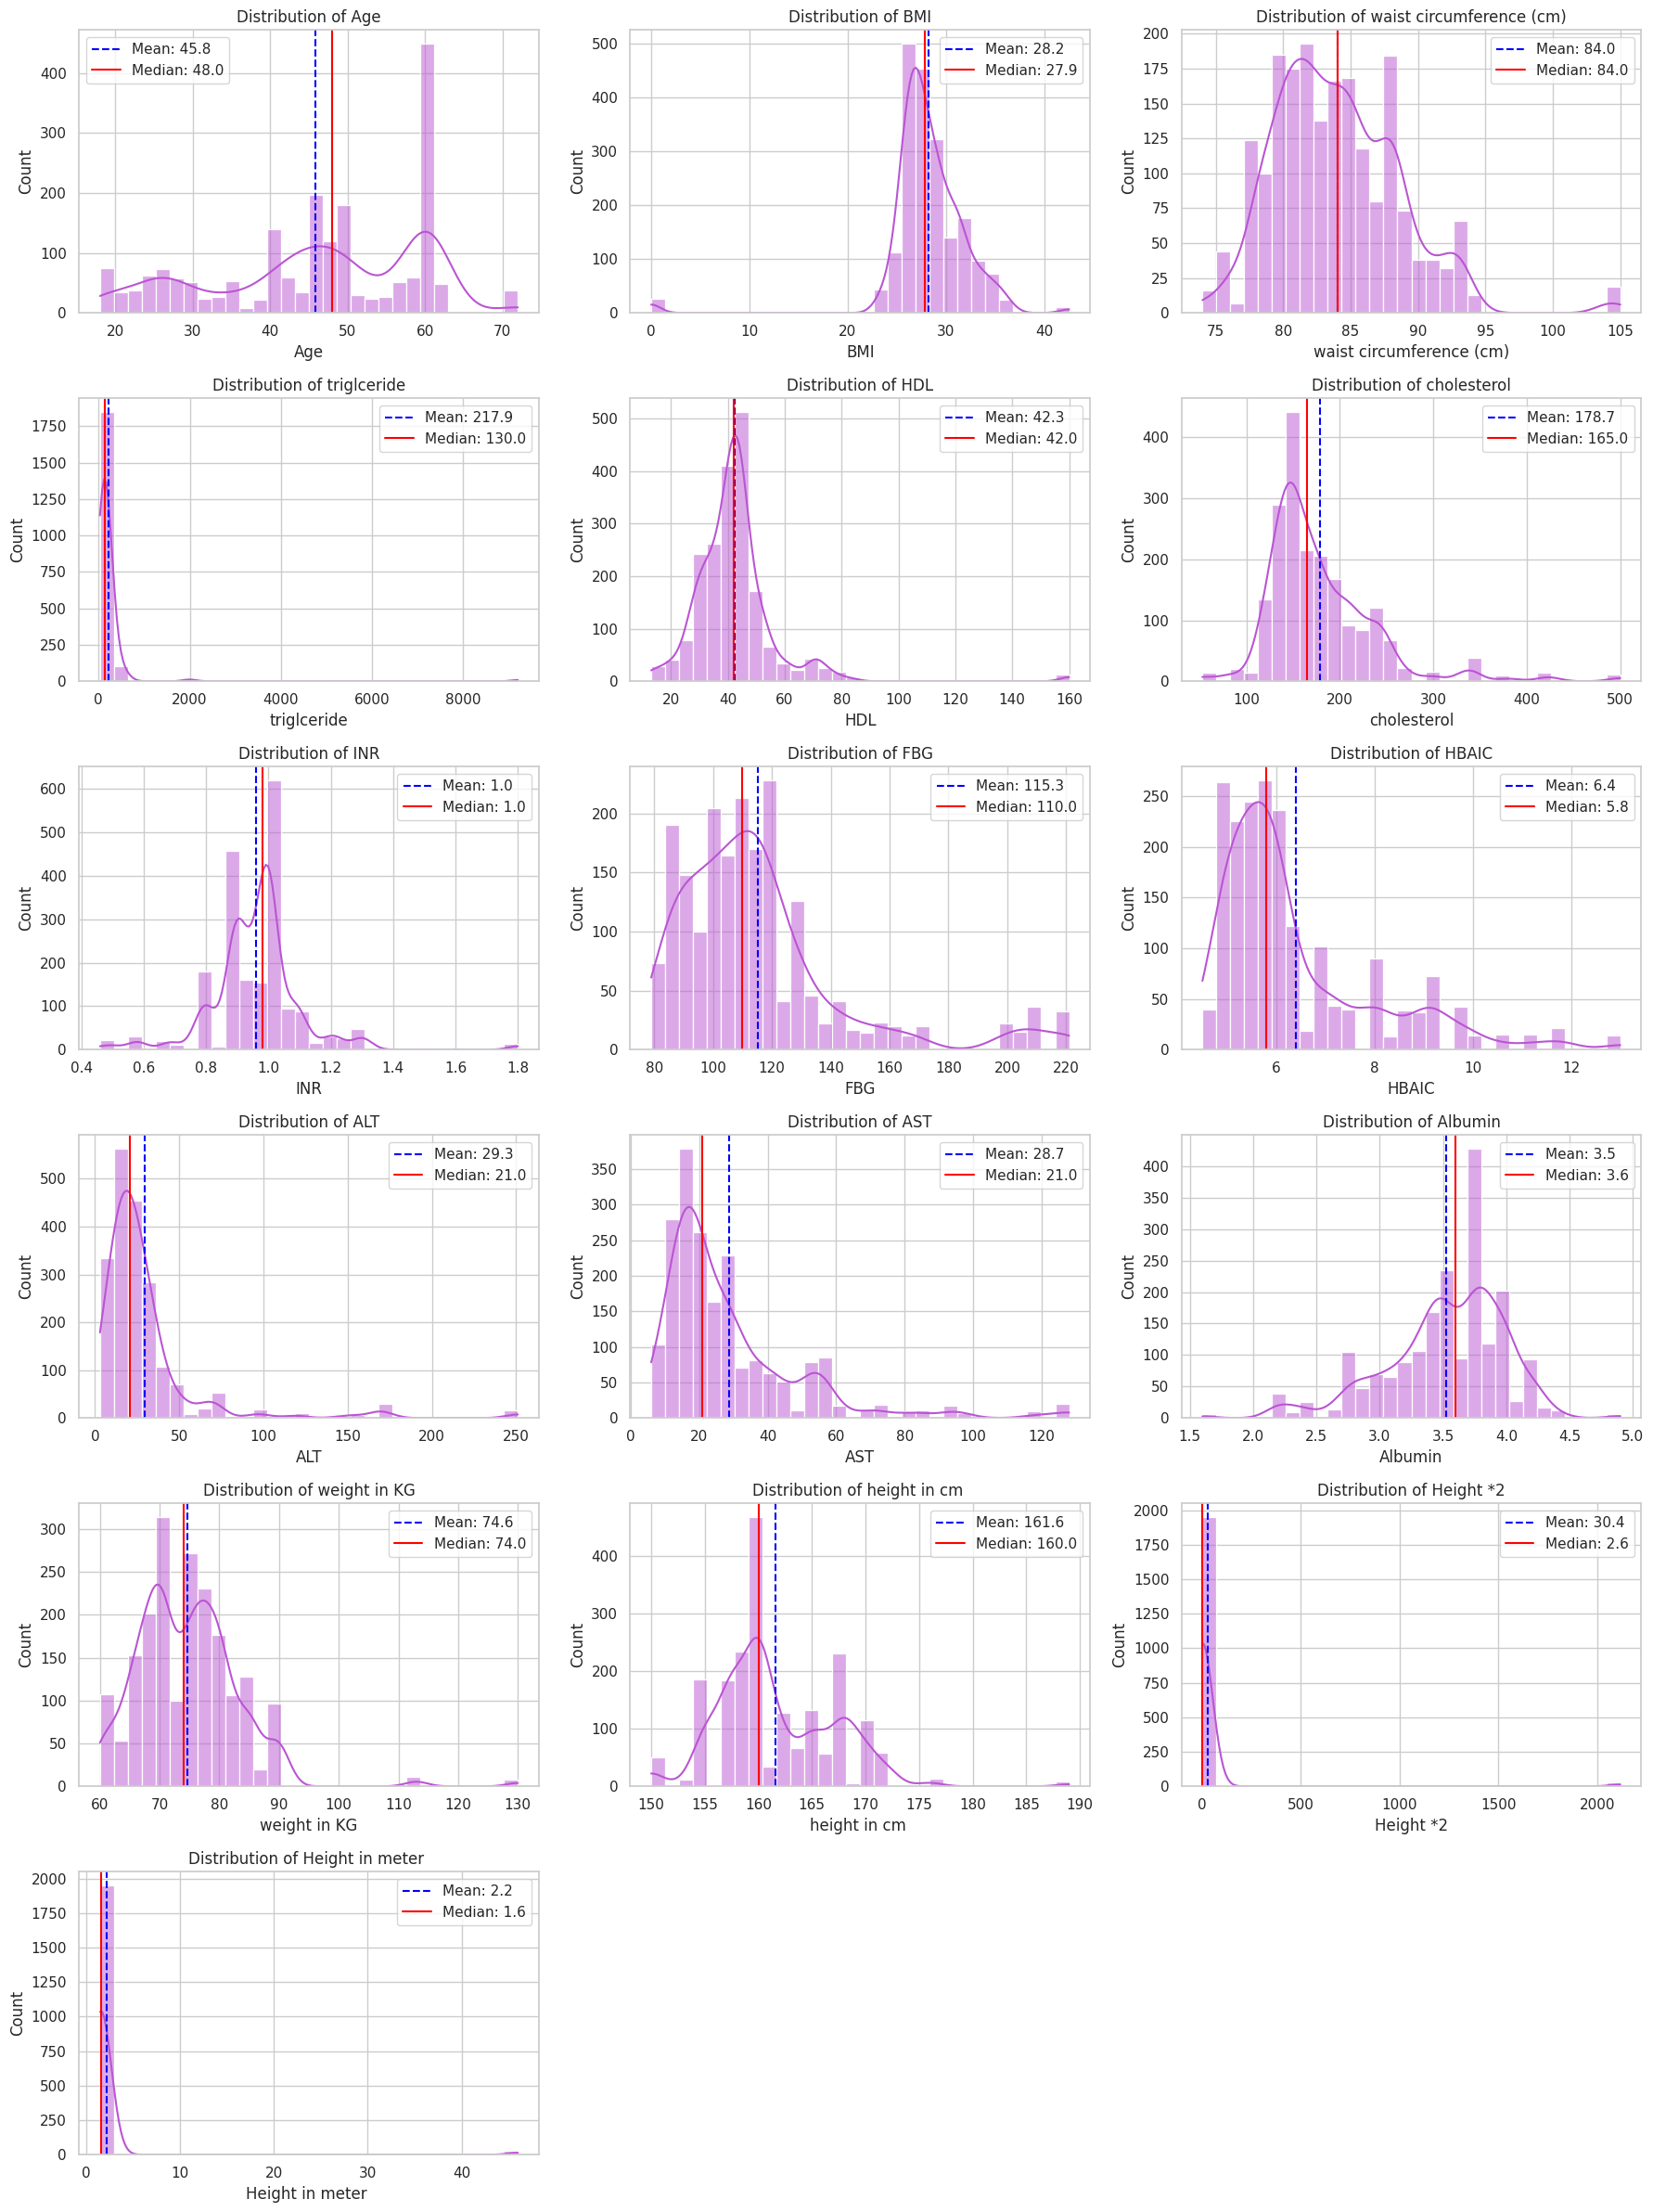

In [25]:
data = tabular_df.select_dtypes('number')
n_cols = 3
n_rows = (len(data.columns[:22]) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()


for i, col in enumerate(data.columns[:22]):
    sns.histplot(x=data[col], ax=axes[i], kde=True, bins=30,color='mediumorchid')


    mean_val = data[col].mean()
    median_val = data[col].median()


    axes[i].axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='red', linestyle='-', label=f'Median: {median_val:.1f}')


    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [26]:
standard_cols = [
    'Age',
    'BMI',
    'waist circumference (cm)',
    'HDL',
    'cholesterol',
    'INR',
    'weight in KG'
]

robust_cols = [
    'FBG',
    'HBAIC',
    'ALT',
    'AST',
    'Albumin',
    'height in cm '
]

In [27]:
standard_scaler = StandardScaler()

train_tabular[standard_cols] = standard_scaler.fit_transform(
    train_tabular[standard_cols]
)

validation_tabular[standard_cols] = standard_scaler.transform(
    validation_tabular[standard_cols]
)

In [28]:
robust_scaler = RobustScaler()

train_tabular[robust_cols] = robust_scaler.fit_transform(
    train_tabular[robust_cols]
)

validation_tabular[robust_cols] = robust_scaler.transform(
    validation_tabular[robust_cols]
)

In [29]:
tabular_cols = tabular_df.columns

> # ***Load Image Mask*** 

In [30]:
def load_image_mask_tabular(
    image_path,
    mask_path,
    tabular,
    label
):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (224, 224)
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0


    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(
        mask,
        channels=1
    )

    mask = tf.image.resize(
        mask,
        (224, 224)
    )

    mask = tf.cast(
        mask,
        tf.float32
    ) / 255.0


    return image, mask, tabular, label

In [31]:
def augment(
    image,
    mask,
    tabular,
    label
):

    seed = tf.random.uniform(
        [2],
        maxval=100000,
        dtype=tf.int32
    )

    image = tf.image.stateless_random_flip_left_right(
        image,
        seed=seed
    )

    mask = tf.image.stateless_random_flip_left_right(
        mask,
        seed=seed
    )

    return image, mask, tabular, label

> # Data Augmentation

On-the-fly augmentation was applied using a random horizontal flip to both the image and its corresponding mask with the same seed, ensuring proper alignment.

This approach does not create or store additional images, so it **saves storage space** while providing different image variations across training epochs. It is a **simple, lightweight, and storage-efficient** augmentation technique that helps reduce overfitting.


> # ***Combain Image & Mask***

In [32]:
def combine_image_mask(
    image,
    mask,
    tabular,
    label
):

    combined = tf.concat(
        [image, mask],
        axis=-1
    )

    return {
        "image_mask_input": combined,
        "tabular_input": tabular
    }, label

In [33]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df['image_path'].values,
        train_df['mask_path'].values,
        train_tabular.values.astype('float32'),
        train_df['label_id'].values
    )
)
train_ds = train_ds.map(
    load_image_mask_tabular,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(batchsize)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

I0000 00:00:1790487031.128623      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790487031.131649      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [34]:
validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        validation_df['image_path'].values,
        validation_df['mask_path'].values,
        validation_tabular.values.astype('float32'),
        validation_df['label_id'].values
    )
)

validation_ds = validation_ds.map(
    load_image_mask_tabular,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.batch(batchsize)

validation_ds = validation_ds.prefetch(
    tf.data.AUTOTUNE
)

In [35]:
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())

print("Batch size:", batchsize)

Train samples: 1779
Validation samples: 198
Train batches: 56
Validation batches: 7
Batch size: 32


> # ***Callback*** 

In [36]:
lr_callback   = callbacks.ReduceLROnPlateau(monitor= 'val_accuracy',factor = 0.1,patience=5)
stop_callback = callbacks.EarlyStopping(monitor= 'val_accuracy',patience=8)
model_ckpt = callbacks.ModelCheckpoint("densenet121_model.h5",save_best_only=True,monitor="val_accuracy",mode="max")

> # ***DenseNet121***

In [37]:
def build_model():

    # ==========================================
    # IMAGE + MASK INPUT
    # ==========================================

    image_input = layers.Input(
        shape=(224, 224, 4),
        name="image_mask_input"
    )

    x_img = layers.Conv2D(
        filters=3,
        kernel_size=1,
        padding='same',
        name='convert_4_to_3'
    )(image_input)


    # ==========================================
    # DENSENET121
    # ==========================================

    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )

    # Initially freeze DenseNet
    base_model.trainable = False

    x_img = base_model(
        x_img,
        training=False
    )

    x_img = layers.GlobalAveragePooling2D(
        name='image_gap'
    )(x_img)

    x_img = layers.BatchNormalization(
        name='image_bn'
    )(x_img)

    x_img = layers.Dropout(
        0.4,
        name='image_dropout'
    )(x_img)


    # ==========================================
    # TABULAR INPUT
    # ==========================================

    num_tabular_features = len(tabular_cols)

    tabular_input = layers.Input(
        shape=(num_tabular_features,),
        name="tabular_input"
    )

    x_tab = layers.Dense(
        128,
        activation='relu',
        name='tabular_dense_1'
    )(tabular_input)

    x_tab = layers.BatchNormalization(
        name='tabular_bn_1'
    )(x_tab)

    x_tab = layers.Dropout(
        0.3,
        name='tabular_dropout_1'
    )(x_tab)

    x_tab = layers.Dense(
        64,
        activation='relu',
        name='tabular_dense_2'
    )(x_tab)

    x_tab = layers.BatchNormalization(
        name='tabular_bn_2'
    )(x_tab)

    x_tab = layers.Dropout(
        0.3,
        name='tabular_dropout_2'
    )(x_tab)


    # ==========================================
    # FUSION
    # ==========================================

    combined = layers.Concatenate(
        name='feature_fusion'
    )([
        x_img,
        x_tab
    ])


    # ==========================================
    # CLASSIFICATION HEAD
    # ==========================================

    x = layers.Dense(
        128,
        activation='relu',
        name='fusion_dense'
    )(combined)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        0.4,
        name='fusion_dropout'
    )(x)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name='pred'
    )(x)


    # ==========================================
    # MODEL
    # ==========================================

    model = tf.keras.Model(
        inputs=[
            image_input,
            tabular_input
        ],
        outputs=output,
        name='DenseNet121_Image_Mask_Tabular'
    )


    # ==========================================
    # COMPILE
    # ==========================================

    optimizer = optimizers.Adam(
        learning_rate=1e-3
    )

    loss = losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    model.summary()

    return model

In [38]:
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    name='densenet121'
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [39]:
Dmodel = build_model()

Model: "DenseNet121_Image_Mask_Tabular"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_mask_input    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense_1     │ (None, 128)       │      2,816 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_4_to_3      │ (None, 224, 224,  │         15 │ image_mask_input… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_bn_1        │ (None, 128)       │        512 │ tabular_dense_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ convert_4_to_3[0… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dropout_1   │ (None, 128)       │          0 │ tabular_bn_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense_2     │ (None, 64)        │      8,256 │ tabular_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_bn            │ (None, 1024)      │      4,096 │ image_gap[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_bn_2        │ (None, 64)        │        256 │ tabular_dense_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 1024)      │          0 │ image_bn[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dropout_2   │ (None, 64)        │          0 │ tabular_bn_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 1088)      │          0 │ image_dropout[0]… │
│ (Concatenate)       │                   │            │ tabular_dropout_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 128)       │    139,392 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ fusion_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 128)       │          0 │ batch_normalizat

 Total params: 7,193,875 (27.44 MB)

 Trainable params: 153,683 (600.32 KB)

 Non-trainable params: 7,040,192 (26.86 MB)

In [40]:
history = Dmodel.fit(
    train_ds,
    validation_data = validation_ds,
    callbacks = [lr_callback,model_ckpt],
    epochs = epochs,
    verbose =1
)

Epoch 1/200


2026-09-27 05:31:08.025572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 05:31:08.173594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790487084.252771      81 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.3322 - loss: 2.0175

2026-09-27 05:31:46.100352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 05:31:46.245346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.3332 - loss: 2.0127

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - accuracy: 0.9179 - loss: 0.2025 - val_accuracy: 0.8687 - val_loss: 0.4092 - learning_rate: 1.0000e-04
Epoch 27/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9297 - loss: 0.2068 - val_accuracy: 0.8687 - val_loss: 0.4034 - learning_rate: 1.0000e-04
Epoch 28/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9196 - loss: 0.2066 - val_accuracy: 0.8586 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch 29/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9196 - loss: 0.2102 - val_accuracy: 0.8636 - val_loss: 0.3905 - learning_rate: 1.0000e-04
Epoch 30/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.9309 - loss: 0.1973 - val_accuracy: 0.8586 - val_loss: 0.3916 - learning_rate: 1.0000e-04
Epoch 31/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9398 - loss: 0.1882

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.9370 - loss: 0.1965 - val_accuracy: 0.8788 - val_loss: 0.3859 - learning_rate: 1.0000e-04
Epoch 32/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9325 - loss: 0.1891 - val_accuracy: 0.8737 - val_loss: 0.3820 - learning_rate: 1.0000e-04
Epoch 33/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.9382 - loss: 0.1895 - val_accuracy: 0.8636 - val_loss: 0.3850 - learning_rate: 1.0000e-04
Epoch 34/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.9241 - loss: 0.1978 - val_accuracy: 0.8737 - val_loss: 0.3761 - learning_rate: 1.0000e-04
Epoch 35/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9370 - loss: 0.1817 - val_accuracy: 0.8737 - val_loss: 0.3725 - learning_rate: 1.0000e-04
Epoch 36/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.9415 - loss: 0.1677 - val_accuracy: 0.8788 - val_loss: 0.3642 - learning_rate: 1.0000e-04
Epoch 37/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - ac

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9376 - loss: 0.1878 - val_accuracy: 0.8838 - val_loss: 0.3633 - learning_rate: 1.0000e-05
Epoch 41/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.9410 - loss: 0.1897 - val_accuracy: 0.8838 - val_loss: 0.3633 - learning_rate: 1.0000e-05
Epoch 42/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9183 - loss: 0.2041

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9258 - loss: 0.1945 - val_accuracy: 0.8889 - val_loss: 0.3625 - learning_rate: 1.0000e-05
Epoch 43/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9252 - loss: 0.2216

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.9314 - loss: 0.2057 - val_accuracy: 0.8939 - val_loss: 0.3621 - learning_rate: 1.0000e-05
Epoch 44/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9404 - loss: 0.1768 - val_accuracy: 0.8939 - val_loss: 0.3615 - learning_rate: 1.0000e-05
Epoch 45/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9247 - loss: 0.2027 - val_accuracy: 0.8889 - val_loss: 0.3617 - learning_rate: 1.0000e-05
Epoch 46/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.9370 - loss: 0.1773 - val_accuracy: 0.8889 - val_loss: 0.3621 - learning_rate: 1.0000e-05
Epoch 47/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9410 - loss: 0.1694 - val_accuracy: 0.8889 - val_loss: 0.3617 - learning_rate: 1.0000e-05
Epoch 48/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9337 - loss: 0.1771 - val_accuracy: 0.8889 - val_loss: 0.3614 - learning_rate: 1.0000e-05
Epoch 49/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - ac

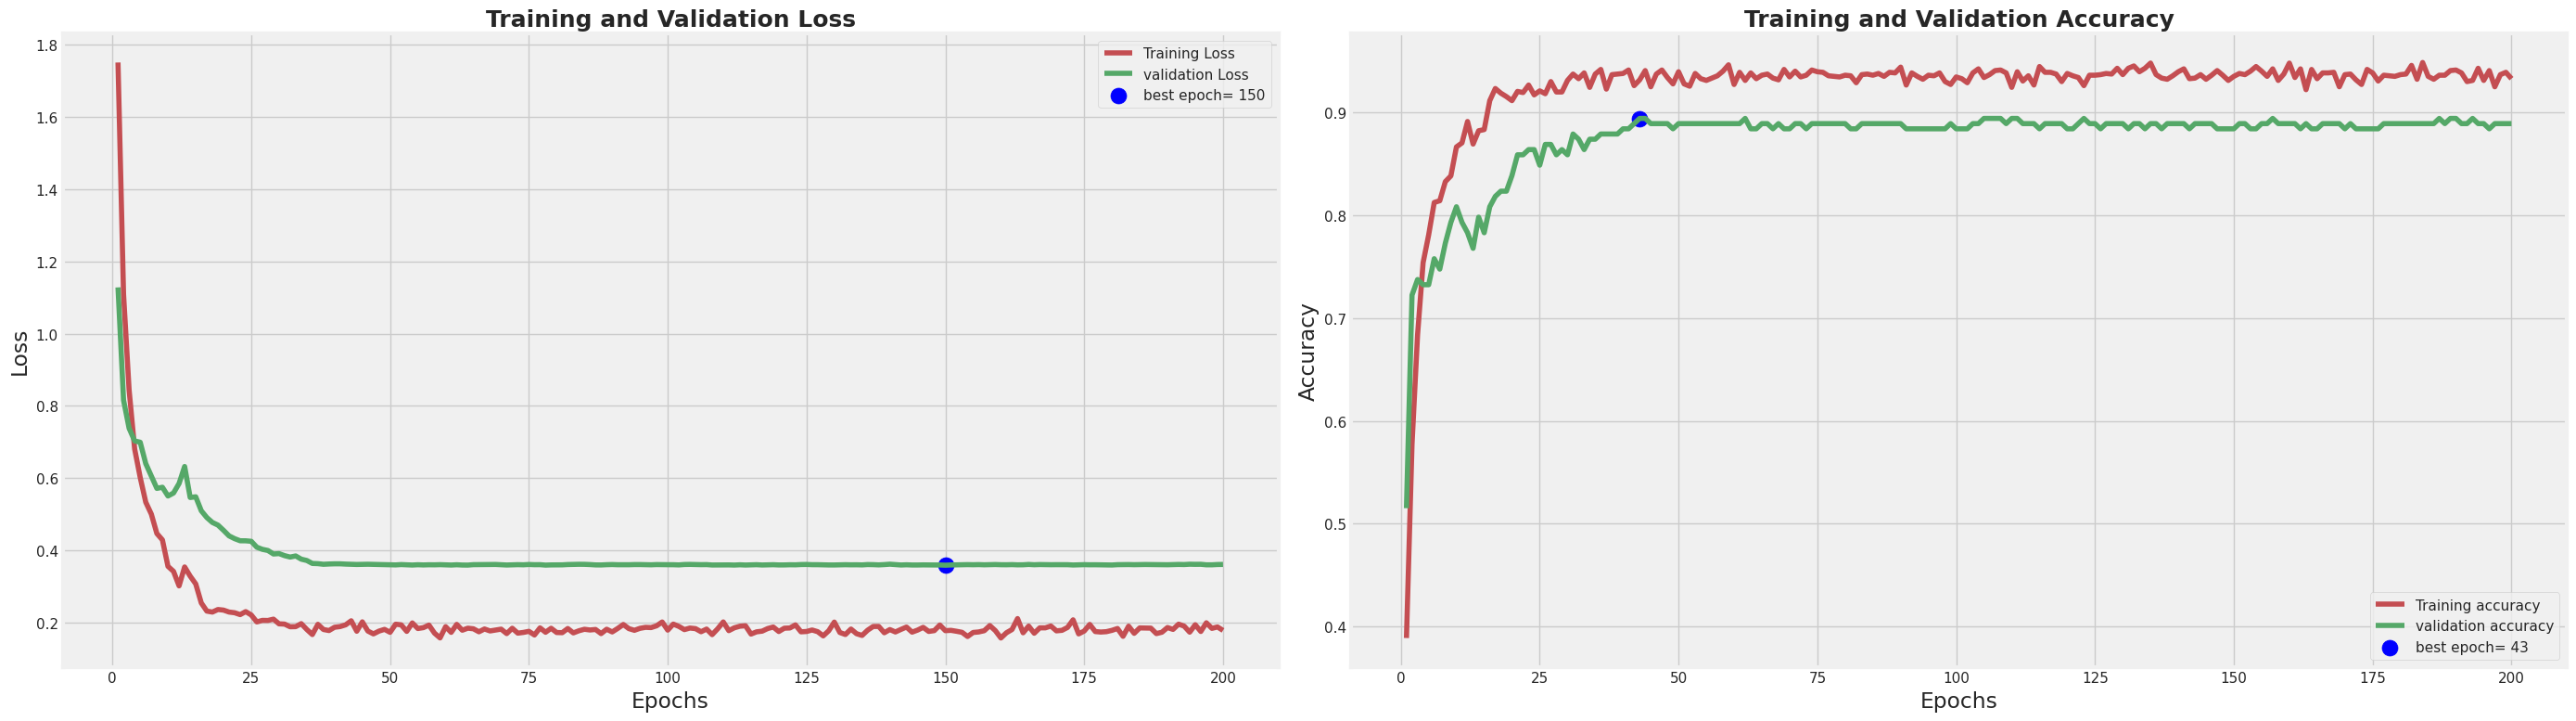

In [41]:
tr_acc   = history.history['accuracy']
tr_loss  = history.history['loss']
val_acc  = history.history['val_accuracy']
val_loss = history.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [42]:
y_test = []
y_pred = []

for inputs, labels in validation_ds:

    preds = Dmodel.predict(
        inputs,
        verbose=0
    )

    preds = np.argmax(
        preds,
        axis=1
    )

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

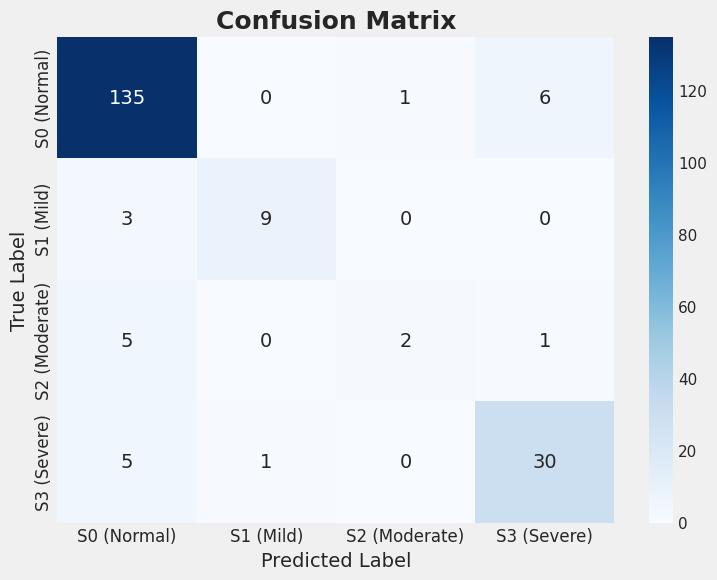

 Classification Report:

               precision    recall  f1-score   support

  S0 (Normal)       0.91      0.95      0.93       142
    S1 (Mild)       0.90      0.75      0.82        12
S2 (Moderate)       0.67      0.25      0.36         8
  S3 (Severe)       0.81      0.83      0.82        36

     accuracy                           0.89       198
    macro avg       0.82      0.70      0.73       198
 weighted avg       0.88      0.89      0.88       198

 Accuracy Score: 0.8889


In [43]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

In [44]:
Dmodel.save("Transfer_DenseNet121.h5")

> # ***Partial Fine Tuning*** 

In [45]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [46]:
Dmodel.compile(
    optimizer=optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [47]:
history_ft = Dmodel.fit(
    train_ds,
    validation_data=validation_ds,
    callbacks=[lr_callback, model_ckpt],
    epochs=100,
    verbose=1
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 81s 869ms/step - accuracy: 0.9342 - loss: 0.1805 - val_accuracy: 0.8889 - val_loss: 0.3614 - learning_rate: 1.0000e-05
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.9438 - loss: 0.1758 - val_accuracy: 0.8889 - val_loss: 0.3610 - learning_rate: 1.0000e-05
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.9438 - loss: 0.1825 - val_accuracy: 0.8838 - val_loss: 0.3615 - learning_rate: 1.0000e-05
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9286 - loss: 0.1912 - val_accuracy: 0.8838 - val_loss: 0.3599 - learning_rate: 1.0000e-05
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9297 - loss: 0.1855 - val_accuracy: 0.8838 - val_loss: 0.3601 - learning_rate: 1.0000e-05
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.9325 - loss: 0.1844 - val_accuracy: 0.8838 - val_loss: 0.3598 - learning_rate: 1.0000e-06
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/ste

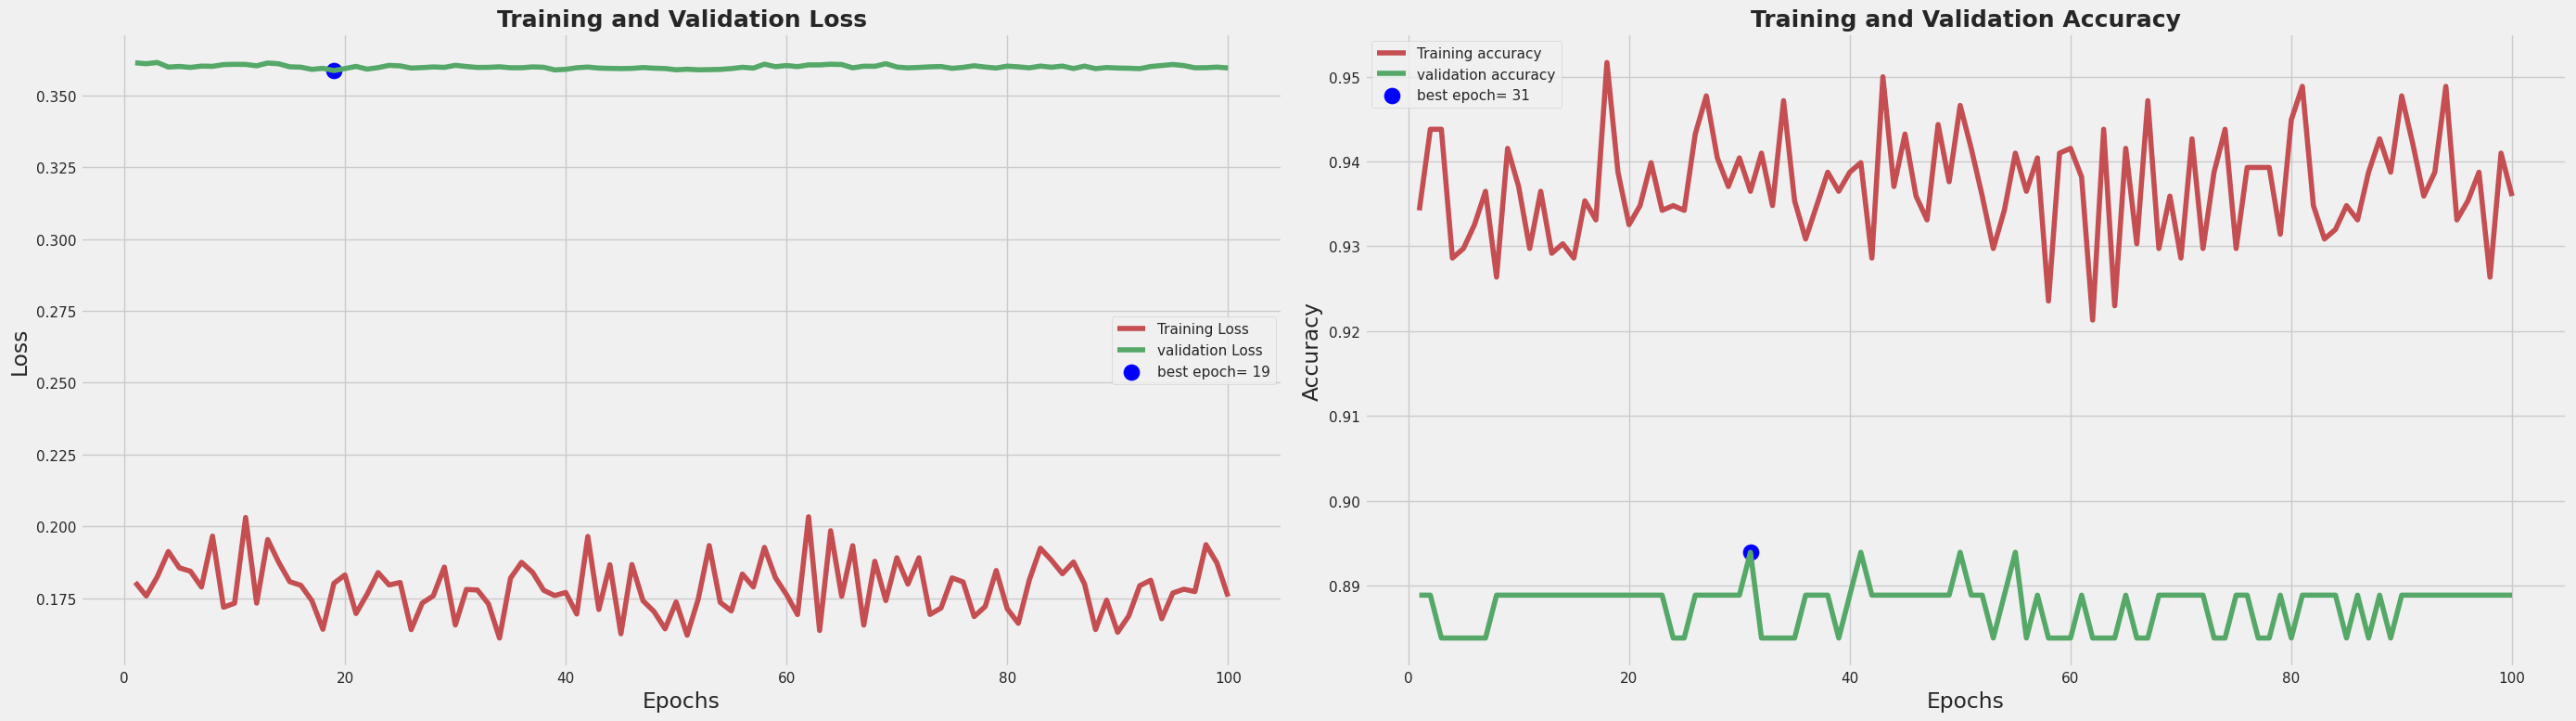

In [48]:
tr_acc   = history_ft.history['accuracy']
tr_loss  = history_ft.history['loss']
val_acc  = history_ft.history['val_accuracy']
val_loss = history_ft.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_Partial_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [49]:
y_test = []
y_pred = []

for inputs, labels in validation_ds:

    preds = Dmodel.predict(
        inputs,
        verbose=0
    )

    preds = np.argmax(
        preds,
        axis=1
    )

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

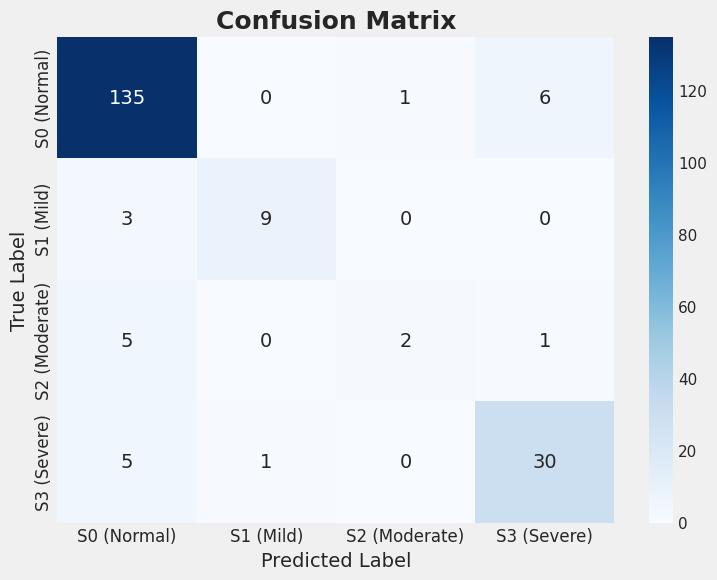

 Classification Report:

               precision    recall  f1-score   support

  S0 (Normal)       0.91      0.95      0.93       142
    S1 (Mild)       0.90      0.75      0.82        12
S2 (Moderate)       0.67      0.25      0.36         8
  S3 (Severe)       0.81      0.83      0.82        36

     accuracy                           0.89       198
    macro avg       0.82      0.70      0.73       198
 weighted avg       0.88      0.89      0.88       198

 Accuracy Score: 0.8889


In [50]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

In [51]:
Dmodel.save("Partial_DenseNet121.h5")

> # ***ResNet50*** 

In [52]:
model_ckpt = callbacks.ModelCheckpoint("ResNet50_model.h5",save_best_only=True,monitor="val_accuracy",mode="max")

In [53]:
def build_model():

    # ==========================================
    # IMAGE + MASK INPUT
    # ==========================================

    image_input = layers.Input(
        shape=(224, 224, 4),
        name="image_mask_input"
    )

    x_img = layers.Conv2D(
        filters=3,
        kernel_size=1,
        padding='same',
        name='convert_4_to_3'
    )(image_input)


    # ==========================================
    # RESNET50
    # ==========================================

    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )

    # Initially freeze DenseNet
    base_model.trainable = False

    x_img = base_model(
        x_img,
        training=False
    )

    x_img = layers.GlobalAveragePooling2D(
        name='image_gap'
    )(x_img)

    x_img = layers.BatchNormalization(
        name='image_bn'
    )(x_img)

    x_img = layers.Dropout(
        0.4,
        name='image_dropout'
    )(x_img)


    # ==========================================
    # TABULAR INPUT
    # ==========================================

    num_tabular_features = len(tabular_cols)

    tabular_input = layers.Input(
        shape=(num_tabular_features,),
        name="tabular_input"
    )

    x_tab = layers.Dense(
        128,
        activation='relu',
        name='tabular_dense_1'
    )(tabular_input)

    x_tab = layers.BatchNormalization(
        name='tabular_bn_1'
    )(x_tab)

    x_tab = layers.Dropout(
        0.3,
        name='tabular_dropout_1'
    )(x_tab)

    x_tab = layers.Dense(
        64,
        activation='relu',
        name='tabular_dense_2'
    )(x_tab)

    x_tab = layers.BatchNormalization(
        name='tabular_bn_2'
    )(x_tab)

    x_tab = layers.Dropout(
        0.3,
        name='tabular_dropout_2'
    )(x_tab)


    # ==========================================
    # FUSION
    # ==========================================

    combined = layers.Concatenate(
        name='feature_fusion'
    )([
        x_img,
        x_tab
    ])


    # ==========================================
    # CLASSIFICATION HEAD
    # ==========================================

    x = layers.Dense(
        128,
        activation='relu',
        name='fusion_dense'
    )(combined)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        0.4,
        name='fusion_dropout'
    )(x)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name='pred'
    )(x)


    # ==========================================
    # MODEL
    # ==========================================

    model = tf.keras.Model(
        inputs=[
            image_input,
            tabular_input
        ],
        outputs=output,
        name='ResNet50_Image_Mask_Tabular'
    )


    # ==========================================
    # COMPILE
    # ==========================================

    optimizer = optimizers.Adam(
        learning_rate=1e-3
    )

    loss = losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    model.summary()

    return model

In [54]:
model = build_model()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50_Image_Mask_Tabular"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_mask_input    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense_1     │ (None, 128)       │      2,816 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_4_to_3      │ (None, 224, 224,  │         15 │ image_mask_input… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_bn_1        │ (None, 128)       │        512 │ tabular_dense_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ convert_4_to_3[0… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dropout_1   │ (None, 128)       │          0 │ tabular_bn_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense_2     │ (None, 64)        │      8,256 │ tabular_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_bn            │ (None, 2048)      │      8,192 │ image_gap[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_bn_2        │ (None, 64)        │        256 │ tabular_dense_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 2048)      │          0 │ image_bn[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dropout_2   │ (None, 64)        │          0 │ tabular_bn_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2112)      │          0 │ image_dropout[0]… │
│ (Concatenate)       │                   │            │ tabular_dropout_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 128)       │    270,464 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ fusion_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 128)       │          0 │ batch_normalizat

 Total params: 23,879,251 (91.09 MB)

 Trainable params: 286,803 (1.09 MB)

 Non-trainable params: 23,592,448 (90.00 MB)

In [55]:
history = model.fit(
    train_ds,
    validation_data = validation_ds,
    callbacks = [lr_callback,model_ckpt],
    epochs = epochs,
    verbose =1
)

Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.3123 - loss: 1.9336

56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 560ms/step - accuracy: 0.3811 - loss: 1.6604 - val_accuracy: 0.2121 - val_loss: 1.3239 - learning_rate: 0.0010
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.5203 - loss: 1.2241

56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - accuracy: 0.5537 - loss: 1.1324 - val_accuracy: 0.4798 - val_loss: 1.1225 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6416 - loss: 0.9376

56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 235ms/step - accuracy: 0.6509 - loss: 0.9040 - val_accuracy: 0.7273 - val_loss: 0.8262 - learning_rate: 0.0010
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - accuracy: 0.7178 - loss: 0.7611 - val_accuracy: 0.7273 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.7504 - loss: 0.6846 - val_accuracy: 0.7273 - val_loss: 0.7287 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7798 - loss: 0.6377

56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.7735 - loss: 0.6311 - val_accuracy: 0.7374 - val_loss: 0.7019 - learning_rate: 1.0000e-04
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7726 - loss: 0.6033

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.7774 - loss: 0.6037 - val_accuracy: 0.7626 - val_loss: 0.6152 - learning_rate: 1.0000e-04
Epoch 11/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 209ms/step - accuracy: 0.7746 - loss: 0.6001 - val_accuracy: 0.7525 - val_loss: 0.6069 - learning_rate: 1.0000e-05
Epoch 12/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8055 - loss: 0.5500

56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.7881 - loss: 0.5993 - val_accuracy: 0.7778 - val_loss: 0.6019 - learning_rate: 1.0000e-05
Epoch 13/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7862 - loss: 0.5669

56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.7763 - loss: 0.5986 - val_accuracy: 0.7879 - val_loss: 0.6009 - learning_rate: 1.0000e-05
Epoch 14/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7909 - loss: 0.5798

56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.7864 - loss: 0.5780 - val_accuracy: 0.7929 - val_loss: 0.5998 - learning_rate: 1.0000e-05
Epoch 15/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - accuracy: 0.7718 - loss: 0.5873 - val_accuracy: 0.7929 - val_loss: 0.5993 - learning_rate: 1.0000e-05
Epoch 16/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7816 - loss: 0.5690

56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 222ms/step - accuracy: 0.7830 - loss: 0.5870 - val_accuracy: 0.8030 - val_loss: 0.6001 - learning_rate: 1.0000e-06
Epoch 17/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.7797 - loss: 0.5874 - val_accuracy: 0.8030 - val_loss: 0.6009 - learning_rate: 1.0000e-06
Epoch 18/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.7701 - loss: 0.5992 - val_accuracy: 0.7929 - val_loss: 0.6014 - learning_rate: 1.0000e-06
Epoch 19/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.7903 - loss: 0.5793 - val_accuracy: 0.7929 - val_loss: 0.6016 - learning_rate: 1.0000e-06
Epoch 20/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.7836 - loss: 0.5897 - val_accuracy: 0.7980 - val_loss: 0.6032 - learning_rate: 1.0000e-06
Epoch 21/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - accuracy: 0.7802 - loss: 0.5647 - val_accuracy: 0.7980 - val_loss: 0.6027 - learning_rate: 1.0000e-07
Epoch 22/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - ac

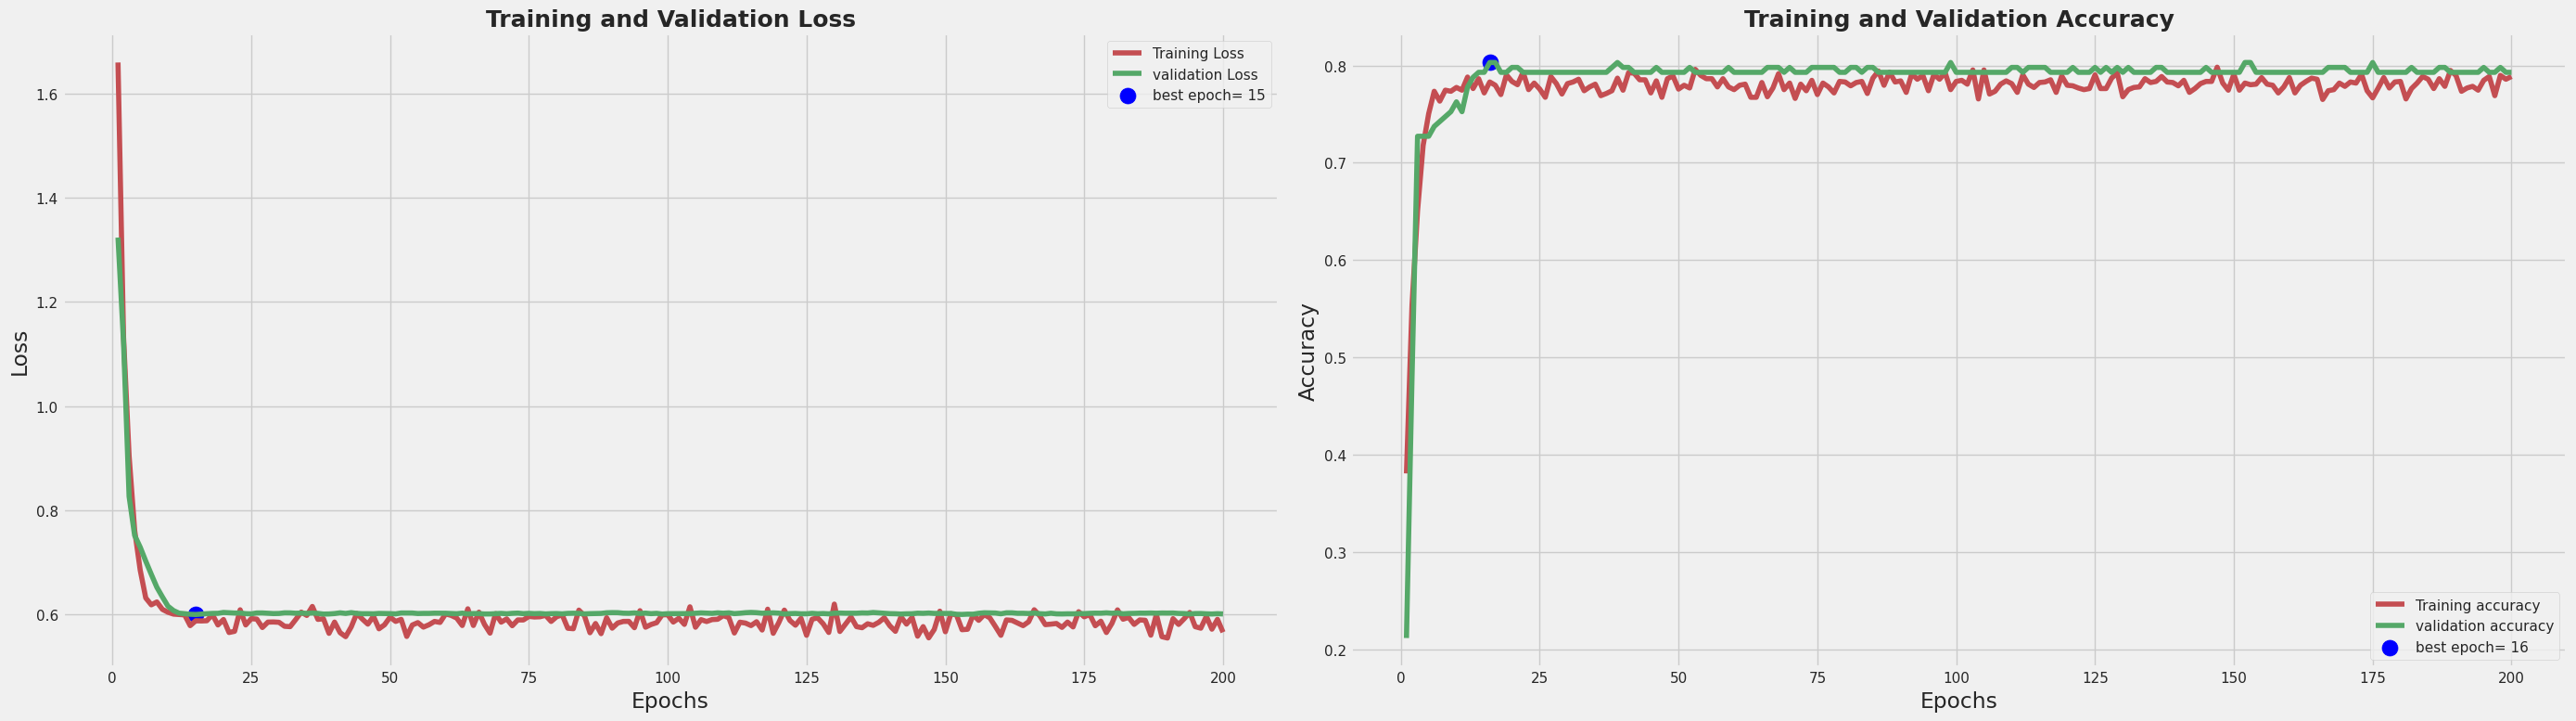

In [56]:
tr_acc   = history.history['accuracy']
tr_loss  = history.history['loss']
val_acc  = history.history['val_accuracy']
val_loss = history.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_ResNet50.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [57]:
y_test = []
y_pred = []

for inputs, labels in validation_ds:

    preds = model.predict(
        inputs,
        verbose=0
    )

    preds = np.argmax(
        preds,
        axis=1
    )

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

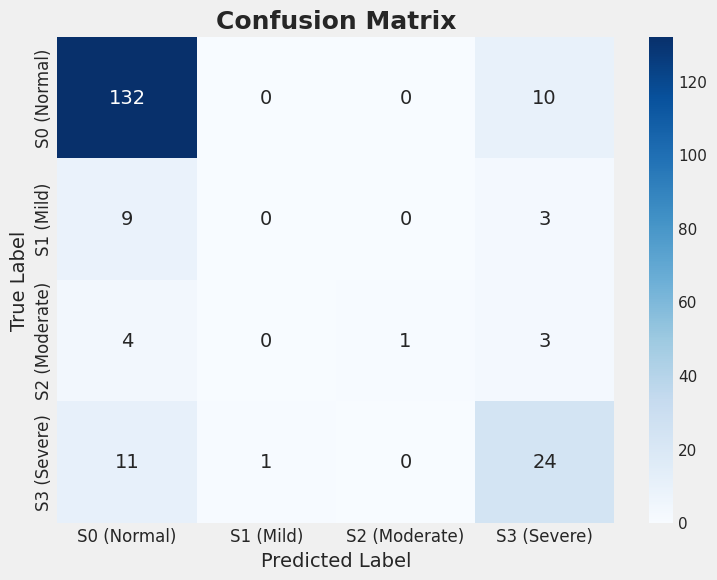

 Classification Report:

               precision    recall  f1-score   support

  S0 (Normal)       0.85      0.93      0.89       142
    S1 (Mild)       0.00      0.00      0.00        12
S2 (Moderate)       1.00      0.12      0.22         8
  S3 (Severe)       0.60      0.67      0.63        36

     accuracy                           0.79       198
    macro avg       0.61      0.43      0.43       198
 weighted avg       0.76      0.79      0.76       198

 Accuracy Score: 0.7929


In [58]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_ResNet50.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

> # ***Save Model***

In [59]:
model.save("final_ResNet50.h5")

> # ***Save PreProcessing*** 

In [60]:
import joblib


joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)
joblib.dump(
    standard_scaler,
    "standard_scaler.pkl"
)

joblib.dump(
    robust_scaler,
    "robust_scaler.pkl"
)

print("Preprocessing objects saved successfully!")

Preprocessing objects saved successfully!
